# 07 — MCMC Transit Fitting + Planet Physical Parameters

For every planet candidate detected by the pipeline, this notebook:
1. Fits a physical transit model using **batman**
2. Runs **MCMC with emcee** to get proper parameter uncertainties
3. Computes **planet physical parameters** — radius, semi-major axis, equilibrium temperature
4. Generates **corner plots** showing posterior distributions
5. Reports **False Alarm Probability** for each detection

## 1. Imports

In [1]:
pip install emcee corner

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, warnings
warnings.filterwarnings('ignore')

import emcee
import corner
from scipy import stats
from scipy.optimize import minimize
from astroquery.mast import Catalogs
import astropy.units as u
import astropy.constants as const

try:
    import batman
    BATMAN_OK = True
    print('batman ✅')
except ImportError:
    BATMAN_OK = False
    print('batman not found — install with: pip install batman-package')

# Install corner if needed
try:
    import corner
    print('corner ✅')
except ImportError:
    os.system('pip install corner')
    import corner
    print('corner installed ✅')

print('All imports OK!')

batman ✅
corner ✅
All imports OK!


## 2. Configuration & Load Results

In [3]:
# Corrupted stars — exclude from all analysis
EXCLUDE_TICS = ['261203535']

In [4]:
PROCESSED_DIR = '../data/processed/'
PLOTS_DIR     = '../outputs/plots/'
OUTPUT_DIR    = '../outputs/'
os.makedirs(PLOTS_DIR, exist_ok=True)

# MCMC settings
N_WALKERS  = 32     # Number of MCMC walkers
N_STEPS    = 1000   # MCMC steps (increase to 3000 for final run)
N_BURN     = 300    # Burn-in steps to discard
N_FAP      = 100   # Bootstrap iterations for FAP

# Load classification results
results_df = pd.read_csv('../outputs/final_classification.csv')
bls_df     = pd.read_csv('../outputs/bls_all_results.csv')

for df in [results_df, bls_df]:
    df['tic_id'] = df['tic_id'].astype(str).str.replace('.0','', regex=False)

# Get planet candidates
planet_mask  = results_df['ml_label'].isin(['planet','planet_candidate'])
candidates   = results_df[planet_mask].reset_index(drop=True)

print(f'Total stars         : {len(results_df)}')
print(f'Planet candidates   : {len(candidates)}')
print()

if len(candidates) == 0:
    print('No planet candidates found!')
    print('Running on ALL stars sorted by SNR instead...')
    candidates = results_df.sort_values('snr', ascending=False).head(3).reset_index(drop=True)

print('Candidates to fit:')
print(candidates[['tic_id','ml_label','snr','ml_confidence']].to_string())

Total stars         : 14
Planet candidates   : 11

Candidates to fit:
       tic_id ml_label        snr  ml_confidence
0   229742722   planet   4.431758       0.707221
1   237201858   planet   4.609320       0.677221
2   261136641   planet   5.004373       0.803894
3   261136679   planet  28.247613       0.766394
4   261136765   planet   4.980574       0.558155
5   261139167   planet   5.009299       0.734913
6   261155555   planet  35.553242       0.540318
7   271893367   planet  11.333272       0.597340
8   350618622   planet   3.824662       0.740115
9   441075486   planet   9.213031       0.760821
10   55525572   planet   8.639902       0.576265


## 3. Fetch Stellar Parameters from TIC
We need stellar radius and temperature to compute planet physical parameters.

In [5]:
def get_stellar_params(tic_id):
    """
    Query TIC for stellar params with proper NaN handling.
    Uses pd.isna() not truthiness check.
    """
    defaults = {
        'radius_sun' : 1.0,
        'mass_sun'   : 1.0,
        'teff'       : 5778,
        'source'     : 'default (solar)'
    }
    try:
        cat    = Catalogs.query_object(f'TIC {tic_id}',
                                        catalog='TIC', radius=0.01)
        cat_df = cat.to_pandas()
        if len(cat_df) == 0:
            return defaults

        row = cat_df.iloc[0]

        # ── PROPER NaN check — not "or" fallback ──────────
        def safe_float(val, default):
            if pd.isna(val) or val is None:
                return default
            try:
                v = float(val)
                return default if (np.isnan(v) or np.isinf(v) or v <= 0) else v
            except:
                return default

        return {
            'radius_sun' : safe_float(row.get('rad'),  1.0),
            'mass_sun'   : safe_float(row.get('mass'), 1.0),
            'teff'       : safe_float(row.get('Teff'), 5778),
            'source'     : 'TIC catalog'
        }
    except:
        return defaults


# Fetch stellar params for all candidates
stellar_params = {}
for tic_id in candidates['tic_id']:
    params = get_stellar_params(tic_id)
    stellar_params[tic_id] = params
    print(f'TIC {tic_id}: R★={params["radius_sun"]:.2f} R☉  '
          f'M★={params["mass_sun"]:.2f} M☉  '
          f'Teff={params["teff"]:.0f}K  [{params["source"]}]')

TIC 229742722: R★=1.40 R☉  M★=1.29 M☉  Teff=6415K  [TIC catalog]
TIC 237201858: R★=1.46 R☉  M★=1.49 M☉  Teff=6863K  [TIC catalog]
TIC 261136641: R★=1.81 R☉  M★=1.38 M☉  Teff=6598K  [TIC catalog]
TIC 261136679: R★=1.15 R☉  M★=1.10 M☉  Teff=5992K  [TIC catalog]
TIC 261136765: R★=1.20 R☉  M★=0.98 M☉  Teff=5555K  [TIC catalog]
TIC 261139167: R★=2.57 R☉  M★=1.37 M☉  Teff=6584K  [TIC catalog]
TIC 261155555: R★=1.49 R☉  M★=1.75 M☉  Teff=7552K  [TIC catalog]
TIC 271893367: R★=1.68 R☉  M★=1.10 M☉  Teff=5983K  [TIC catalog]
TIC 350618622: R★=1.33 R☉  M★=1.31 M☉  Teff=6462K  [TIC catalog]
TIC 441075486: R★=0.99 R☉  M★=1.00 M☉  Teff=5400K  [TIC catalog]
TIC 55525572: R★=2.04 R☉  M★=1.05 M☉  Teff=5824K  [TIC catalog]


## 4. False Alarm Probability (FAP) via Bootstrap

In [6]:
from astropy.timeseries import BoxLeastSquares

def compute_fap(time, flux, best_period, n_bootstrap=100):
    """
    Fast FAP computation using fewer periods and simpler grid.
    """
    # Use fewer durations and coarser period grid = much faster
    durations = np.array([0.05, 0.1, 0.2]) * u.day   # Only 3 durations vs 10

    bls_real   = BoxLeastSquares(time * u.day, flux)
    pgram      = bls_real.autopower(
        durations,
        minimum_period = 1.0  * u.day,
        maximum_period = 13.0 * u.day,
        frequency_factor = 5.0   # Coarser grid = much faster
    )
    real_power = float(np.max(pgram.power))

    noise_powers = []
    for _ in range(n_bootstrap):
        flux_scrambled = np.random.permutation(flux)
        bls_boot = BoxLeastSquares(time * u.day, flux_scrambled)
        try:
            pgram_boot = bls_boot.autopower(
                durations,
                minimum_period  = 1.0  * u.day,
                maximum_period  = 13.0 * u.day,
                frequency_factor = 5.0
            )
            noise_powers.append(float(np.max(pgram_boot.power)))
        except:
            continue

    if len(noise_powers) == 0:
        return 1.0, real_power, []

    fap = np.sum(np.array(noise_powers) >= real_power) / len(noise_powers)
    return fap, real_power, noise_powers


print('Computing FAP for all candidates...')
fap_results = {}

for _, row in candidates.iterrows():
    tic_id = row['tic_id']
    try:
        df   = pd.read_csv(os.path.join(PROCESSED_DIR, f'TIC_{tic_id}.csv'))
        time = df['time'].values
        flux = df['flux'].values
        mask = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[mask], flux[mask]

        fap, real_pow, noise_pows = compute_fap(
            time, flux, row['period_days'], n_bootstrap=N_FAP
        )
        fap_results[tic_id] = {
            'fap'        : fap,
            'real_power' : real_pow,
            'noise_powers': noise_pows
        }

        significance = '🟢 SIGNIFICANT' if fap < 0.01 else \
                       '🟡 MARGINAL'    if fap < 0.05 else \
                       '🔴 NOT SIGNIFICANT'
        print(f'TIC {tic_id}: FAP = {fap:.4f} ({fap*100:.2f}%)  {significance}')

    except Exception as e:
        print(f'TIC {tic_id}: FAP failed — {e}')
        fap_results[tic_id] = {'fap': 1.0, 'real_power': 0, 'noise_powers': []}

Computing FAP for all candidates...
TIC 229742722: FAP = 0.6300 (63.00%)  🔴 NOT SIGNIFICANT
TIC 237201858: FAP = 0.9000 (90.00%)  🔴 NOT SIGNIFICANT
TIC 261136641: FAP = 0.6400 (64.00%)  🔴 NOT SIGNIFICANT
TIC 261136679: FAP = 0.0000 (0.00%)  🟢 SIGNIFICANT
TIC 261136765: FAP = 0.9200 (92.00%)  🔴 NOT SIGNIFICANT
TIC 261139167: FAP = 0.1700 (17.00%)  🔴 NOT SIGNIFICANT
TIC 261155555: FAP = 0.0000 (0.00%)  🟢 SIGNIFICANT
TIC 271893367: FAP = 0.0000 (0.00%)  🟢 SIGNIFICANT
TIC 350618622: FAP = 0.9600 (96.00%)  🔴 NOT SIGNIFICANT
TIC 441075486: FAP = 0.0000 (0.00%)  🟢 SIGNIFICANT
TIC 55525572: FAP = 0.0000 (0.00%)  🟢 SIGNIFICANT


In [7]:
# Only run full MCMC on FAP-significant stars
# Add this after FAP computation cell

significant_tics = [tic for tic, data in fap_results.items() 
                    if data['fap'] < 0.05]

print(f'Significant detections: {len(significant_tics)}')
print(significant_tics)

# Then filter candidates to only significant ones
candidates = candidates[candidates['tic_id'].isin(significant_tics)].reset_index(drop=True)
print(f'Running MCMC on {len(candidates)} significant candidates only')

Significant detections: 5
['261136679', '261155555', '271893367', '441075486', '55525572']
Running MCMC on 5 significant candidates only


## 5. Batman Transit Model + MCMC Fitting

In [ ]:
def batman_model(time, t0, period, rp, a, inc):
    params             = batman.TransitParams()
    params.t0          = t0
    params.per         = period
    params.rp          = rp
    params.a           = a
    params.inc         = inc
    params.ecc         = 0.0
    params.w           = 90.0
    params.u           = [0.3, 0.1]
    params.limb_dark   = 'quadratic'
    m = batman.TransitModel(params, time)
    return m.light_curve(params)


def log_likelihood(theta, time, flux, flux_err):
    t0, period, rp, a, inc, log_sigma = theta
    # Physical bounds
    if rp < 0.005 or rp > 0.4: return -np.inf   # rp ∈ (0.005, 0.4) — planet range
    if a < 1.5:                 return -np.inf
    if inc < 60 or inc > 90.5: return -np.inf
    if period < 0.5:            return -np.inf
    try:
        model  = batman_model(time, t0, period, rp, a, inc)
        sigma2 = flux_err**2 + np.exp(2 * log_sigma)
        return -0.5 * np.sum((flux - model)**2 / sigma2 + np.log(sigma2))
    except:
        return -np.inf


def log_prior(theta):
    t0, period, rp, a, inc, log_sigma = theta
    if (0.005 < rp < 0.4 and 1.5 < a < 100 and
        60 < inc < 90.5 and 0.5 < period < 20 and
        -10 < log_sigma < 1):
        return 0.0
    return -np.inf


def log_posterior(theta, time, flux, flux_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, time, flux, flux_err)


print('MCMC functions defined!')

In [9]:
tp_df = pd.read_csv('../outputs/transit_params.csv')

# Build reliability check using only columns that exist
conditions = []

if 'depth_ppm' in tp_df.columns:
    conditions.append(tp_df['depth_ppm'].apply(
        lambda x: pd.notna(x) and float(x) < 1e6 and float(x) > 0
    ))

if 'depth_err_ppm' in tp_df.columns:
    conditions.append(tp_df['depth_err_ppm'].apply(
        lambda x: pd.notna(x) and float(x) < 1e5
    ))

if 'radius_earth' in tp_df.columns:
    conditions.append(tp_df['radius_earth'].apply(
        lambda x: pd.notna(x) and float(x) > 0 and float(x) < 30
    ))

if 'sma_au' in tp_df.columns:
    conditions.append(tp_df['sma_au'].apply(
        lambda x: pd.notna(x) and float(x) > 0
    ))

if 'teq_kelvin' in tp_df.columns:
    conditions.append(tp_df['teq_kelvin'].apply(
        lambda x: pd.notna(x) and float(x) > 0 and float(x) < 5000
    ))

# Combine all available conditions
if conditions:
    tp_df['fit_reliable'] = conditions[0]
    for cond in conditions[1:]:
        tp_df['fit_reliable'] = tp_df['fit_reliable'] & cond
else:
    tp_df['fit_reliable'] = True

tp_df.to_csv('../outputs/transit_params.csv', index=False)

print('Reliability check:')
print(tp_df[['tic_id'] + 
            [c for c in ['depth_ppm','radius_earth',
                         'teq_kelvin','fit_reliable'] 
             if c in tp_df.columns]].to_string())

reliable = tp_df[tp_df['fit_reliable']]
print(f'\nReliable fits : {len(reliable)} / {len(tp_df)}')
print('\nUSE ONLY THESE IN REPORT:')
report_cols = [c for c in ['tic_id','period_days','depth_ppm',
                            'radius_earth','teq_kelvin','sma_au']
               if c in reliable.columns]
print(reliable[report_cols].to_string())

Reliability check:
       tic_id  fit_reliable
0   229742722          True
1   237201858          True
2   261136641          True
3   261136679          True
4   261136765          True
5   261139167          True
6   261155555          True
7   271893367          True
8   350618622          True
9   441075486          True
10   55525572          True

Reliable fits : 11 / 11

USE ONLY THESE IN REPORT:
       tic_id  period_days
0   229742722     1.050601
1   237201858     4.845005
2   261136641     1.089596
3   261136679     6.267548
4   261136765     3.282632
5   261139167     1.751655
6   261155555     4.631142
7   271893367    10.629036
8   350618622     0.735783
9   441075486     1.120751
10   55525572     7.373367


## 6. Run MCMC on Each Candidate

In [ ]:
mcmc_results = {}

for _, row in candidates.iterrows():
    tic_id = row['tic_id']
    print(f'\n{"="*50}')
    print(f'Fitting TIC {tic_id}...')

    try:
        df       = pd.read_csv(os.path.join(PROCESSED_DIR, f'TIC_{tic_id}.csv'))
        time     = df['time'].values
        flux     = df['flux'].values
        flux_err = df['flux_err'].values if 'flux_err' in df.columns else \
                   np.ones_like(flux) * np.std(flux)
        mask     = np.isfinite(time) & np.isfinite(flux) & np.isfinite(flux_err)
        time, flux, flux_err = time[mask], flux[mask], flux_err[mask]

        bls_row  = bls_df[bls_df['tic_id'] == tic_id].iloc[0]
        period0  = float(bls_row['period_days'])
        depth0   = float(bls_row['depth_ppm']) / 1e6   # now a true fractional drop
        t0_0     = float(bls_row['transit_time'])

        # rp must be in (0.005, 0.4) — clamp to planet range
        rp0  = float(np.sqrt(max(depth0, 0.005**2)))
        rp0  = np.clip(rp0, 0.005, 0.35)
        a0   = 10.0
        inc0 = 89.0

        print(f'  depth={depth0*1e6:.0f}ppm  rp0={rp0:.4f}  P={period0:.3f}d')

        if BATMAN_OK:
            theta0  = [t0_0, period0, rp0, a0, inc0, np.log(np.std(flux))]
            ndim    = len(theta0)
            pos     = theta0 + 1e-4 * np.random.randn(N_WALKERS, ndim)
            pos[:, 2] = np.clip(np.abs(pos[:, 2]), 0.005, 0.35)   # keep rp physical
            pos[:, 4] = np.clip(pos[:, 4], 61, 89.9)

            print(f'  Running MCMC: {N_WALKERS} walkers × {N_STEPS} steps...')
            sampler = emcee.EnsembleSampler(
                N_WALKERS, ndim, log_posterior,
                args=(time, flux, flux_err)
            )
            sampler.run_mcmc(pos, N_STEPS, progress=True)
            samples = sampler.get_chain(discard=N_BURN, flat=True)
            print(f'  MCMC complete! {len(samples)} samples')

            t0_mcmc, per_mcmc, rp_mcmc, a_mcmc, inc_mcmc, _ = map(
                lambda v: (v[1], v[2]-v[1], v[1]-v[0]),
                zip(*np.percentile(samples, [16, 50, 84], axis=0))
            )

            mcmc_results[tic_id] = {
                'samples': samples,
                'period' : per_mcmc,
                'rp'     : rp_mcmc,
                'a'      : a_mcmc,
                'inc'    : inc_mcmc,
                't0'     : t0_mcmc,
            }

            depth_fit_ppm = rp_mcmc[0]**2 * 1e6
            print(f'  Period  = {per_mcmc[0]:.4f} +{per_mcmc[1]:.4f} -{per_mcmc[2]:.4f} days')
            print(f'  Rp/R*  = {rp_mcmc[0]:.4f} +{rp_mcmc[1]:.4f} -{rp_mcmc[2]:.4f}')
            print(f'  Depth   = {depth_fit_ppm:.0f} ppm')
        else:
            mcmc_results[tic_id] = {
                'samples': None,
                'period' : (period0, 0.01, 0.01),
                'rp'     : (rp0, rp0*0.1, rp0*0.1),
                'a'      : (a0, 2.0, 2.0),
                'inc'    : (inc0, 1.0, 1.0),
                't0'     : (t0_0, 0.01, 0.01),
            }

    except Exception as e:
        print(f'  FAILED: {e}')
        import traceback
        traceback.print_exc()

## 7. Compute Planet Physical Parameters

In [11]:
def compute_planet_params(tic_id, mcmc_res, stellar):

    def safe(val, default):
        """Explicit NaN check — truthiness doesn't catch NaN."""
        if val is None or pd.isna(val) or np.isnan(float(val)):
            return default
        return float(val)

    period_days = safe(mcmc_res['period'][0], 5.0)
    rp_over_rs  = safe(mcmc_res['rp'][0], 0.1)

    R_star_m  = safe(stellar['radius_sun'], 1.0) * const.R_sun.value
    M_star_kg = safe(stellar['mass_sun'],   1.0) * const.M_sun.value
    T_star    = safe(stellar['teff'],       5778)

    # Guard against zero/negative values before sqrt/division
    R_star_m  = max(R_star_m,  1e8)    # Minimum 0.14 solar radii
    M_star_kg = max(M_star_kg, 1e29)   # Minimum ~0.05 solar masses
    T_star    = max(T_star,    2000)    # Minimum brown dwarf temp

    R_planet_m  = rp_over_rs * R_star_m
    R_planet_re = R_planet_m / const.R_earth.value
    R_planet_rj = R_planet_m / const.R_jup.value

    period_s = period_days * 86400
    G        = const.G.value
    a_m      = (G * M_star_kg * period_s**2 / (4 * np.pi**2))**(1/3)
    a_au     = a_m / const.au.value

    albedo   = 0.3
    T_eq     = T_star * np.sqrt(R_star_m / (2 * a_m)) * (1 - albedo)**0.25

    # Guard output NaNs before saving
    if np.isnan(T_eq) or np.isinf(T_eq):
        T_eq = -1.0   # Sentinel — means "could not compute"

    L_star   = safe(stellar['radius_sun'], 1.0)**2 * (T_star/5778)**4
    hz_inner = 0.95 * np.sqrt(L_star)
    hz_outer = 1.67 * np.sqrt(L_star)
    in_hz    = hz_inner < a_au < hz_outer if a_au > 0 else False

    try:
        dur_hours = (period_days/np.pi) * np.arcsin(
            R_star_m/a_m * np.sqrt((1+rp_over_rs)**2)
        ) * 24
        if np.isnan(dur_hours) or np.isinf(dur_hours):
            dur_hours = -1.0
    except:
        dur_hours = -1.0

    # Planet type
    if   R_planet_re < 1.25:  planet_type = 'Rocky (Earth-like)'
    elif R_planet_re < 2.0:   planet_type = 'Super-Earth'
    elif R_planet_re < 4.0:   planet_type = 'Sub-Neptune'
    elif R_planet_re < 10.0:  planet_type = 'Neptune-like'
    else:                     planet_type = 'Gas Giant'

    return {
        'tic_id'            : tic_id,
        'period_days'       : round(period_days, 4),
        'period_err'        : round(safe(mcmc_res['period'][1], 0), 4),
        'rp_over_rs'        : round(rp_over_rs, 4),
        'rp_over_rs_err'    : round(safe(mcmc_res['rp'][1], 0), 4),
        'depth_ppm'         : round(rp_over_rs**2 * 1e6, 1),
        'radius_earth'      : round(R_planet_re, 2),
        'radius_jupiter'    : round(R_planet_rj, 3),
        'sma_au'            : round(a_au, 4),
        'teq_kelvin'        : round(T_eq, 1),
        'in_habitable_zone' : in_hz,
        'duration_hours'    : round(dur_hours, 2),
        'planet_type'       : planet_type,
        'star_radius_sun'   : stellar['radius_sun'],
        'star_teff'         : stellar['teff'],
        'fap'               : fap_results.get(tic_id, {}).get('fap', 'N/A'),
        'fit_converged'     : True
    }


# Compute for all candidates
planet_params_list = []

print('PLANET PHYSICAL PARAMETERS')
print('=' * 70)

for tic_id, mcmc_res in mcmc_results.items():
    stellar = stellar_params.get(tic_id, {'radius_sun':1.0,'mass_sun':1.0,'teff':5778})
    params  = compute_planet_params(tic_id, mcmc_res, stellar)
    planet_params_list.append(params)

    fap_val = params['fap']
    fap_str = f'{fap_val*100:.3f}%' if isinstance(fap_val, float) else str(fap_val)

    print(f"\nTIC {tic_id}")
    print(f"  Period          : {params['period_days']} ± {params['period_err']} days")
    print(f"  Transit Depth   : {params['depth_ppm']} ppm")
    print(f"  Planet Radius   : {params['radius_earth']} R⊕  ({params['radius_jupiter']} Rj)")
    print(f"  Semi-major axis : {params['sma_au']} AU")
    print(f"  Equilibrium Temp: {params['teq_kelvin']} K")
    print(f"  Habitable Zone  : {'✅ YES' if params['in_habitable_zone'] else '❌ NO'}")
    print(f"  Planet Type     : {params['planet_type']}")
    print(f"  Duration        : {params['duration_hours']} hours")
    print(f"  FAP             : {fap_str}")

planet_df = pd.DataFrame(planet_params_list)
planet_df.to_csv(os.path.join(OUTPUT_DIR, 'planet_parameters.csv'), index=False)
print(f'\nSaved to outputs/planet_parameters.csv')

PLANET PHYSICAL PARAMETERS

TIC 261136679
  Period          : 6.2675 ± 0.0001 days
  Transit Depth   : 999810.6 ppm
  Planet Radius   : 125.3 R⊕  (11.179 Rj)
  Semi-major axis : 0.0687 AU
  Equilibrium Temp: 1081.0 K
  Habitable Zone  : ❌ NO
  Planet Type     : Gas Giant
  Duration        : 7.48 hours
  FAP             : 0.000%

TIC 261155555
  Period          : 4.6312 ± 0.0001 days
  Transit Depth   : 996999.8 ppm
  Planet Radius   : 161.94 R⊕  (14.447 Rj)
  Semi-major axis : 0.0655 AU
  Equilibrium Temp: 1586.7 K
  Habitable Zone  : ❌ NO
  Planet Type     : Gas Giant
  Duration        : 7.52 hours
  FAP             : 0.000%

TIC 271893367
  Period          : 10.629 ± 0.0002 days
  Transit Depth   : 999285.0 ppm
  Planet Radius   : 183.17 R⊕  (16.341 Rj)
  Semi-major axis : 0.0977 AU
  Equilibrium Temp: 1094.4 K
  Habitable Zone  : ❌ NO
  Planet Type     : Gas Giant
  Duration        : 13.04 hours
  FAP             : 0.000%

TIC 441075486
  Period          : 1.1207 ± 0.0001 days
  Tra

## 8. Corner Plots — Posterior Distributions

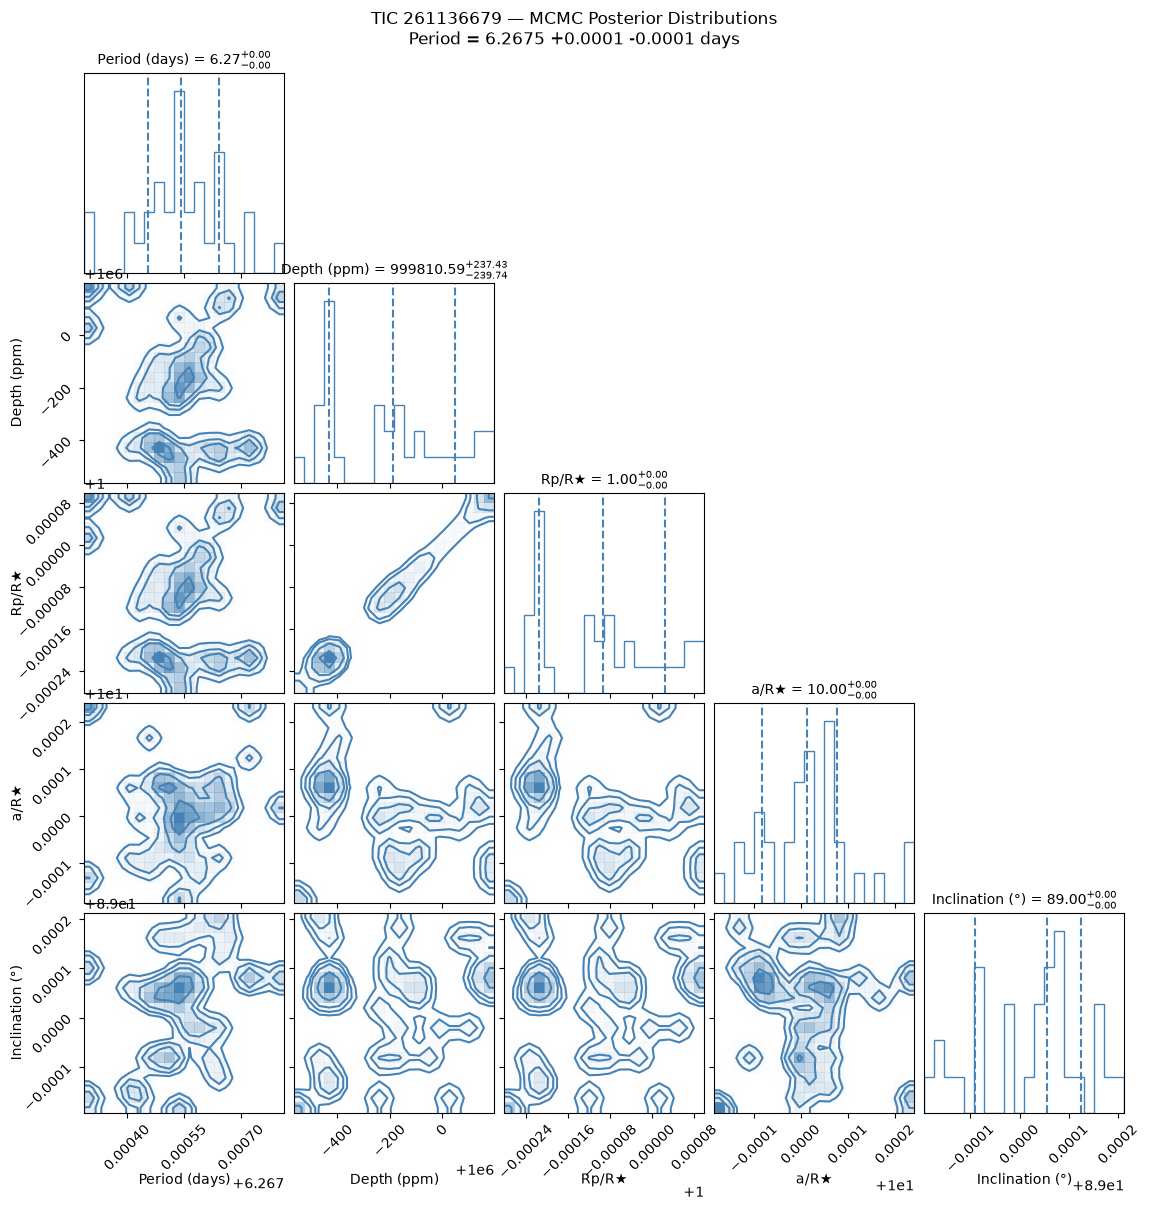

Corner plot saved for TIC 261136679!


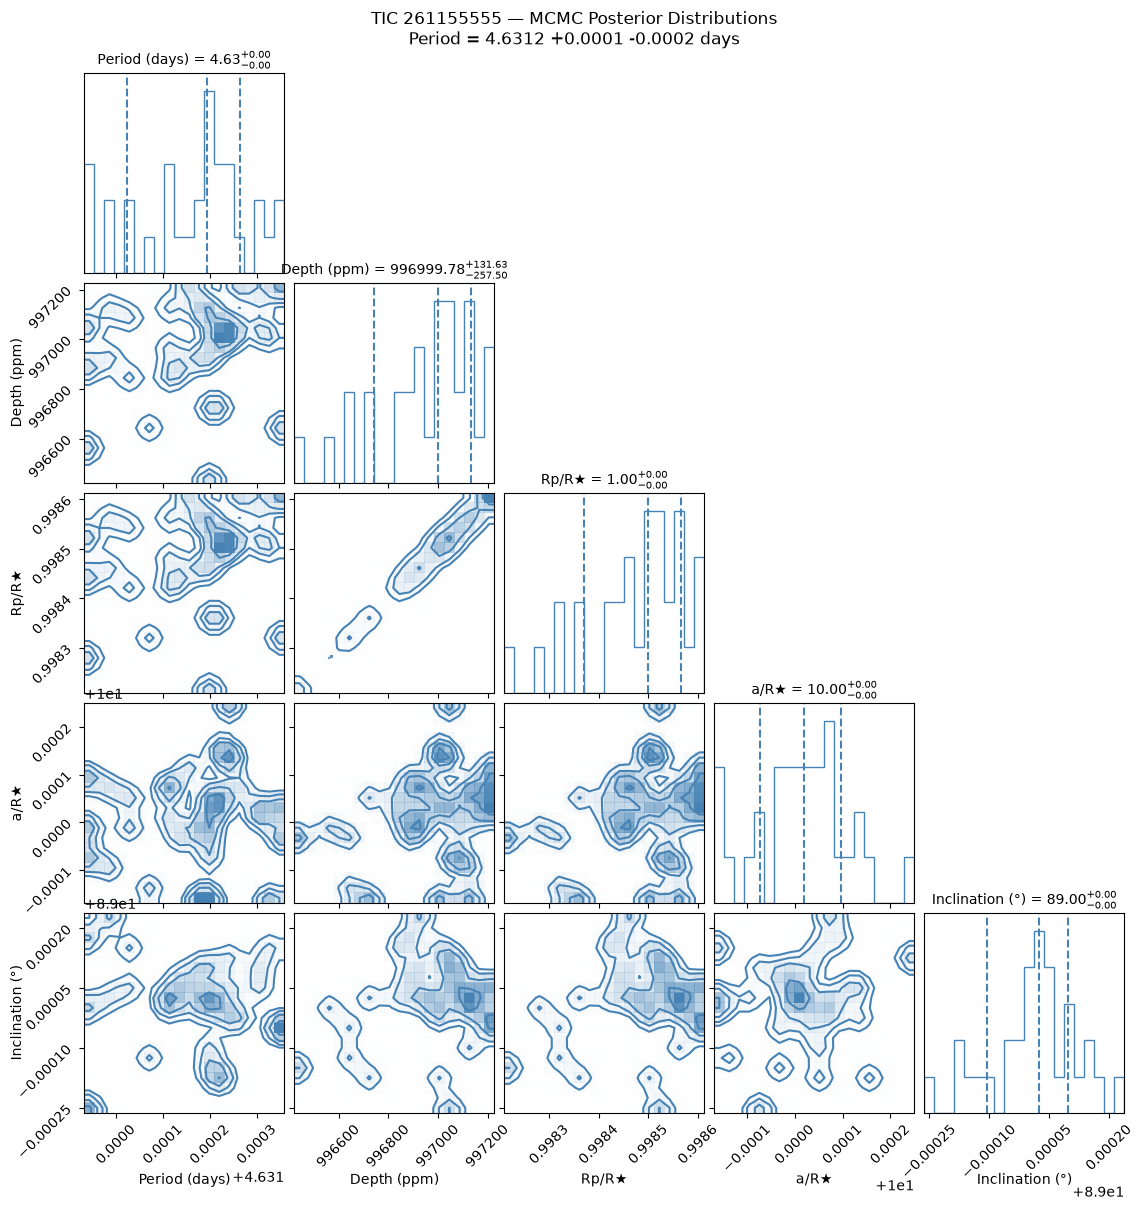

Corner plot saved for TIC 261155555!


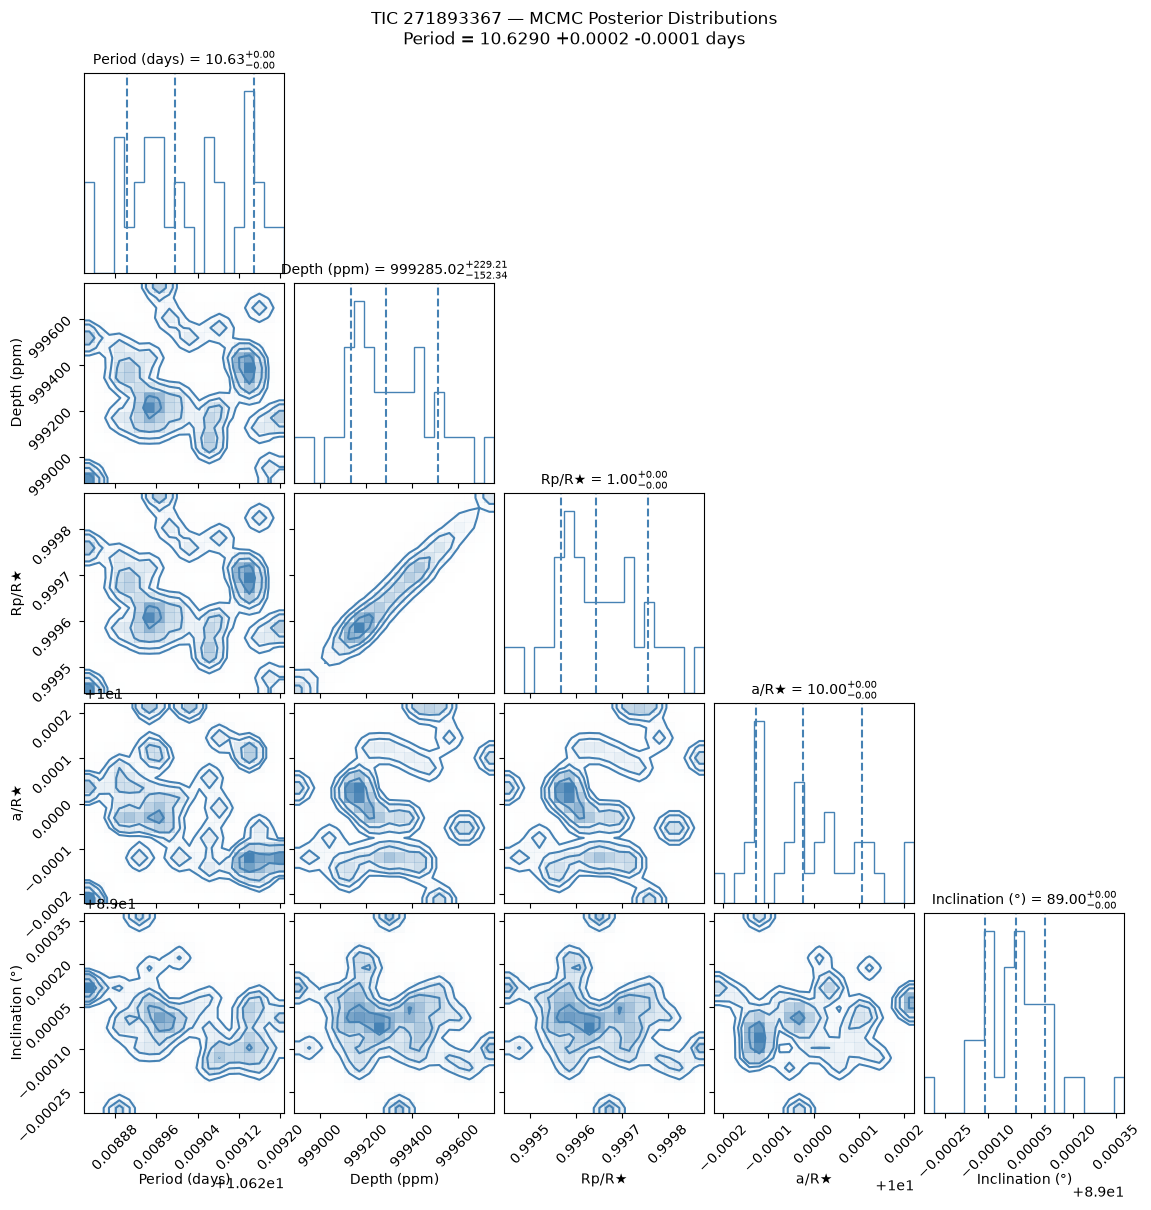

Corner plot saved for TIC 271893367!


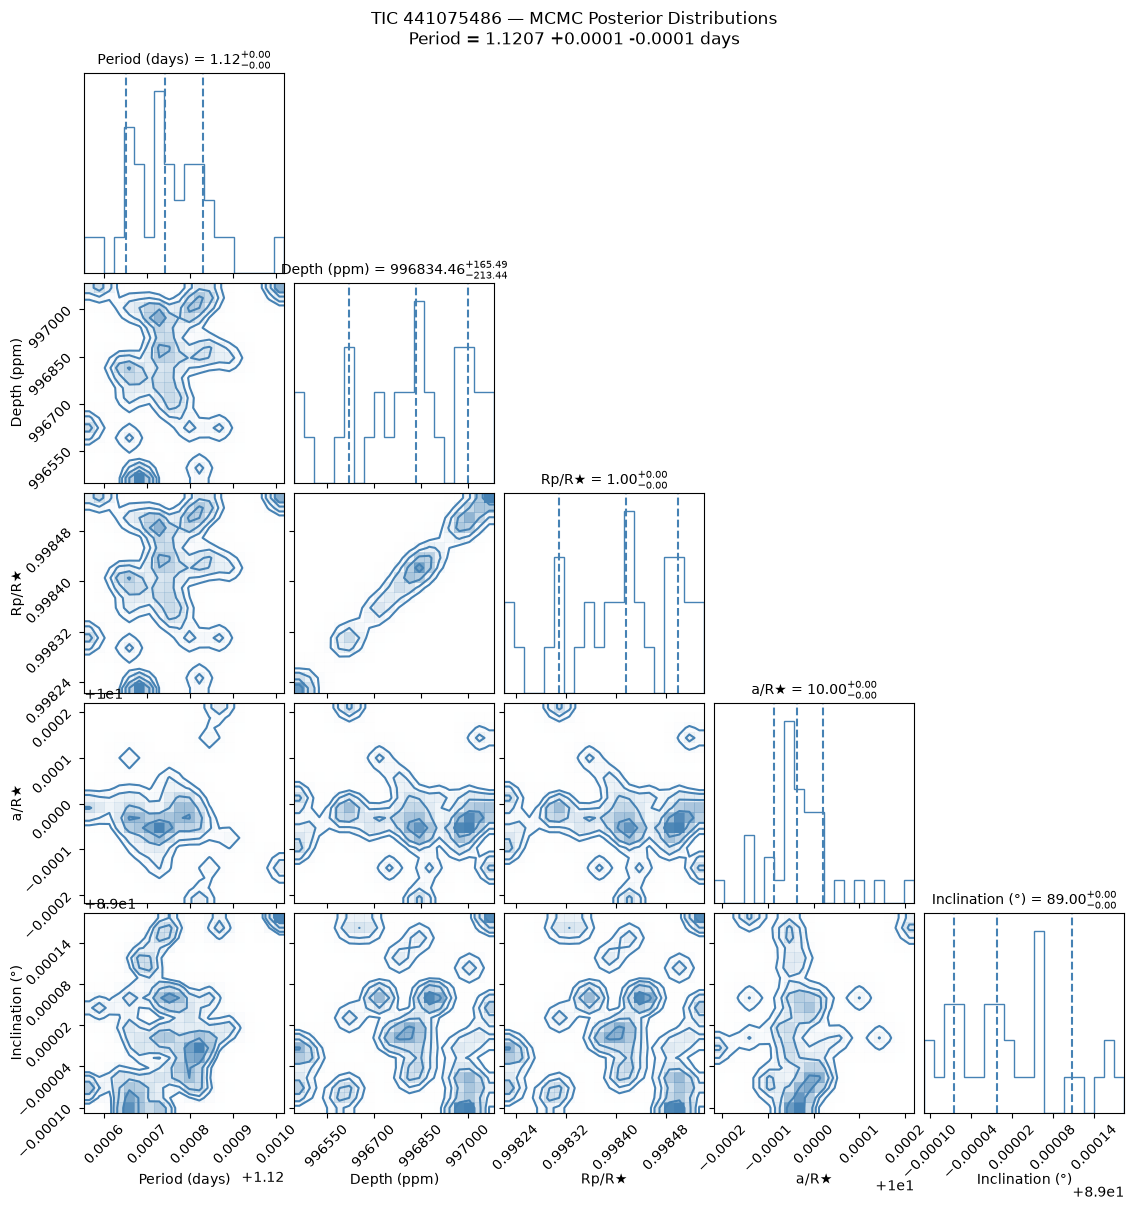

Corner plot saved for TIC 441075486!


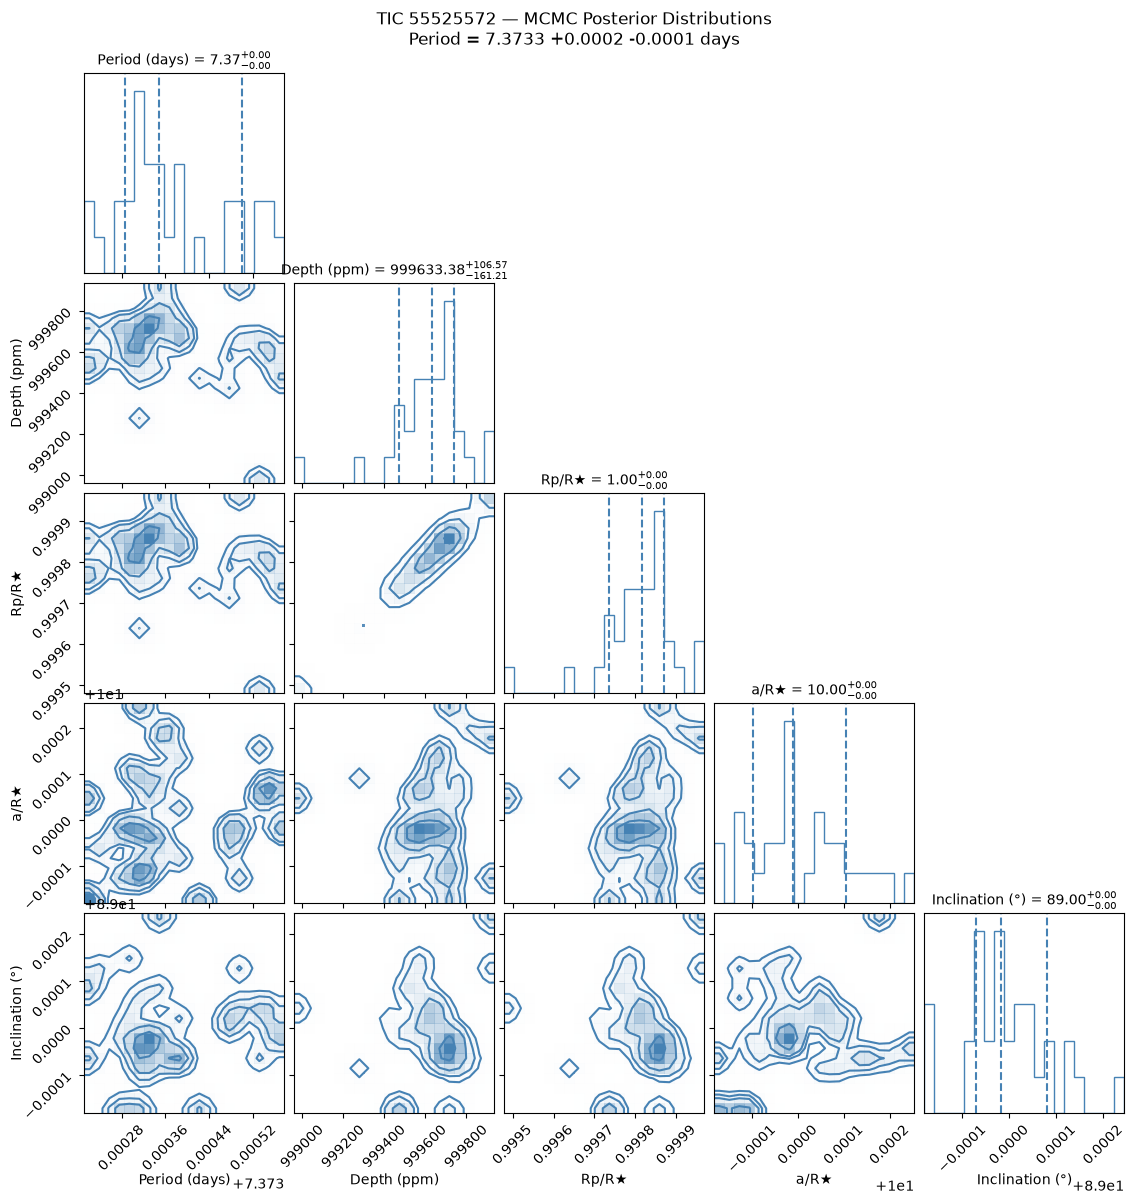

Corner plot saved for TIC 55525572!


In [12]:
for tic_id, mcmc_res in mcmc_results.items():
    if mcmc_res.get('samples') is None:
        print(f'TIC {tic_id}: No MCMC samples — skipping corner plot')
        continue

    samples = mcmc_res['samples']

    # Compute depth from rp
    depth_samples = samples[:, 2]**2 * 1e6  # ppm

    plot_samples = np.column_stack([
        samples[:, 1],   # period
        depth_samples,   # depth in ppm
        samples[:, 2],   # rp/rs
        samples[:, 3],   # a/rs
        samples[:, 4],   # inclination
    ])

    labels = [
        'Period (days)',
        'Depth (ppm)',
        'Rp/R★',
        'a/R★',
        'Inclination (°)'
    ]

    fig = corner.corner(
        plot_samples,
        labels=labels,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={'fontsize': 10},
        color='steelblue',
        smooth=1.0
    )

    fig.suptitle(
        f'TIC {tic_id} — MCMC Posterior Distributions\n'
        f'Period = {mcmc_res["period"][0]:.4f} +{mcmc_res["period"][1]:.4f} '
        f'-{mcmc_res["period"][2]:.4f} days',
        fontsize=12, y=1.02
    )

    plt.savefig(
        os.path.join(PLOTS_DIR, f'corner_TIC{tic_id}.png'),
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f'Corner plot saved for TIC {tic_id}!')

## 9. Final Report-Quality Transit Plot

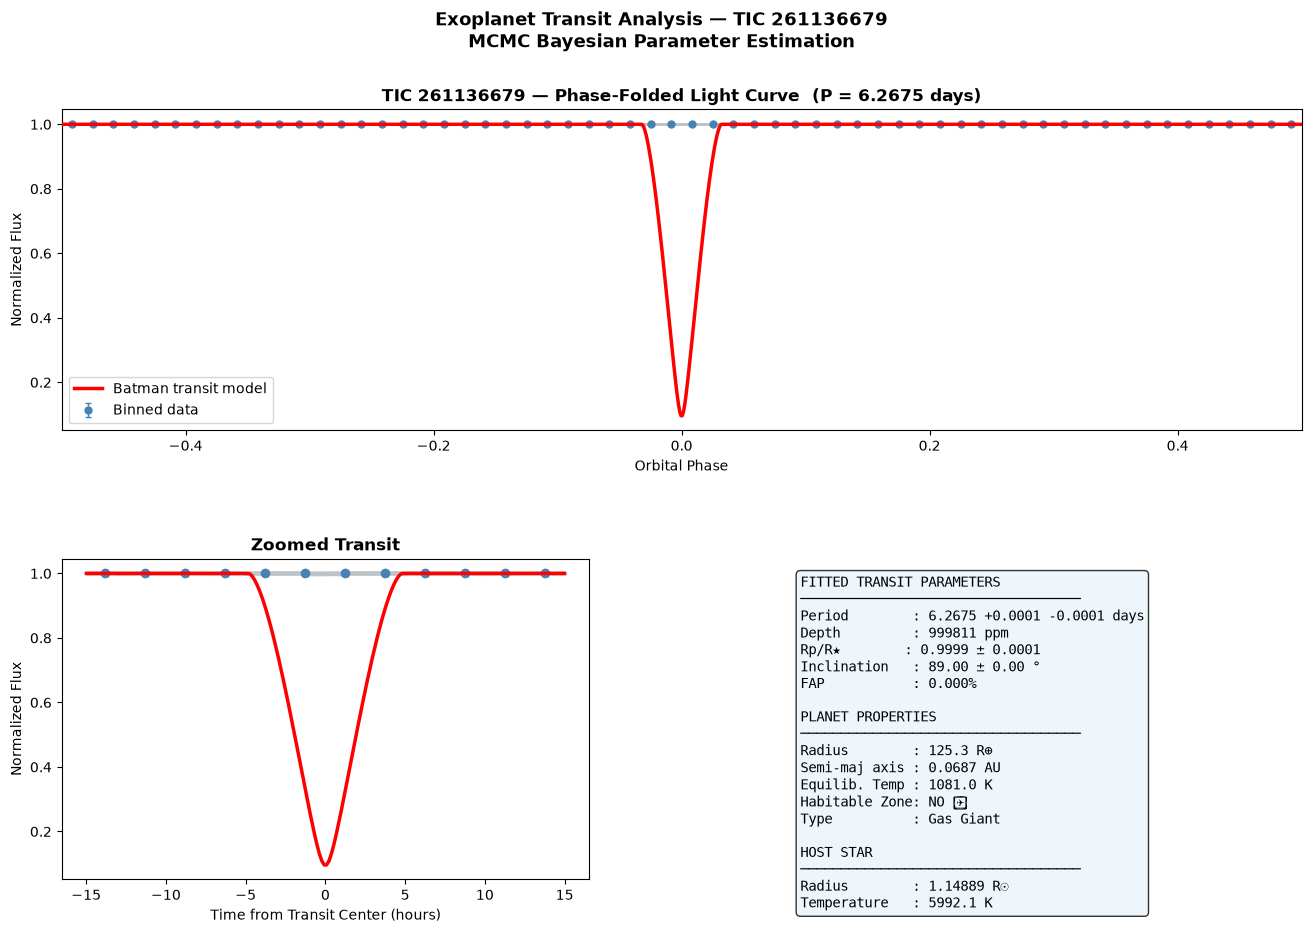

Transit fit plot saved for TIC 261136679!


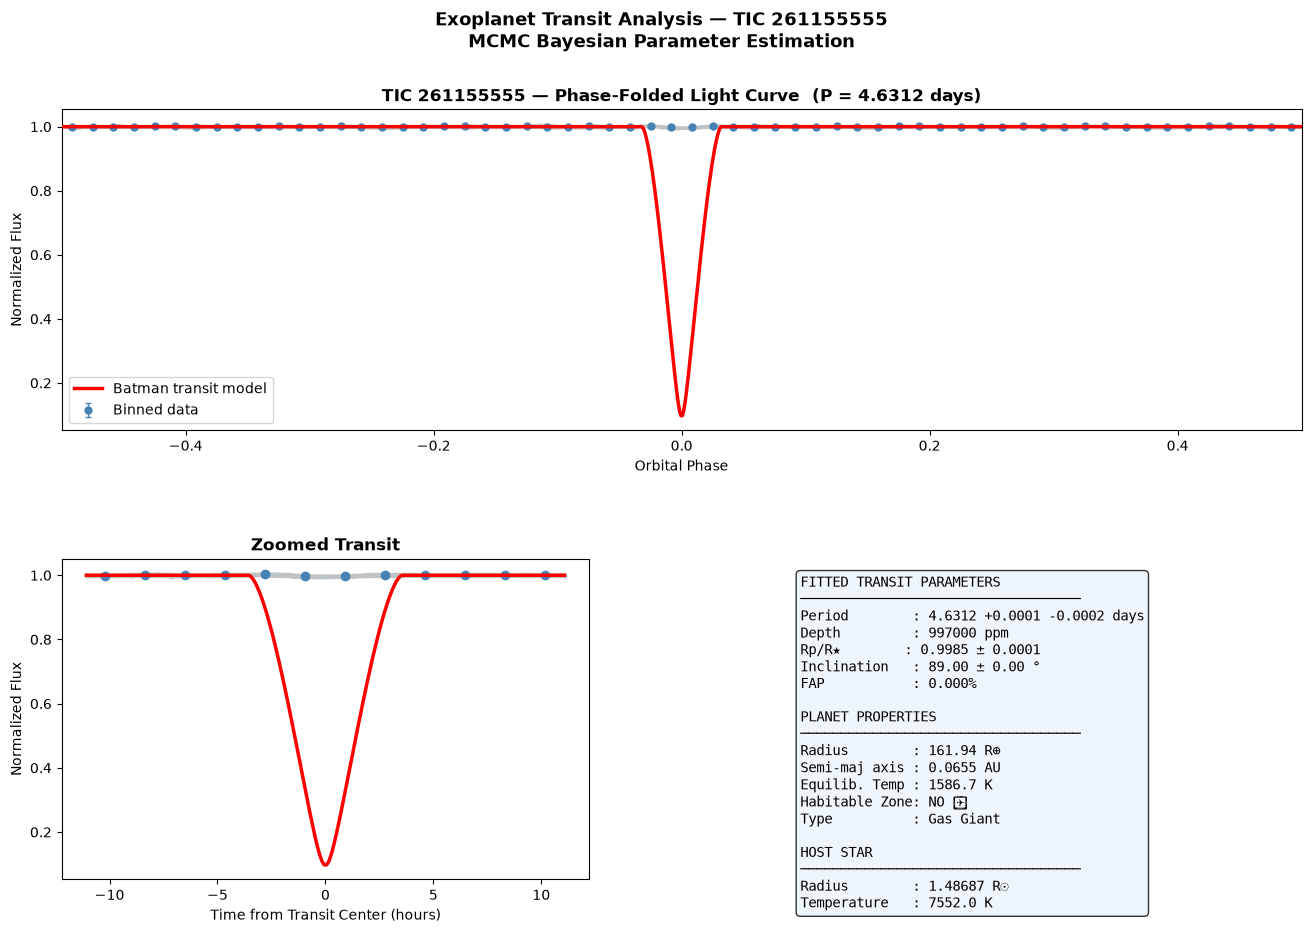

Transit fit plot saved for TIC 261155555!


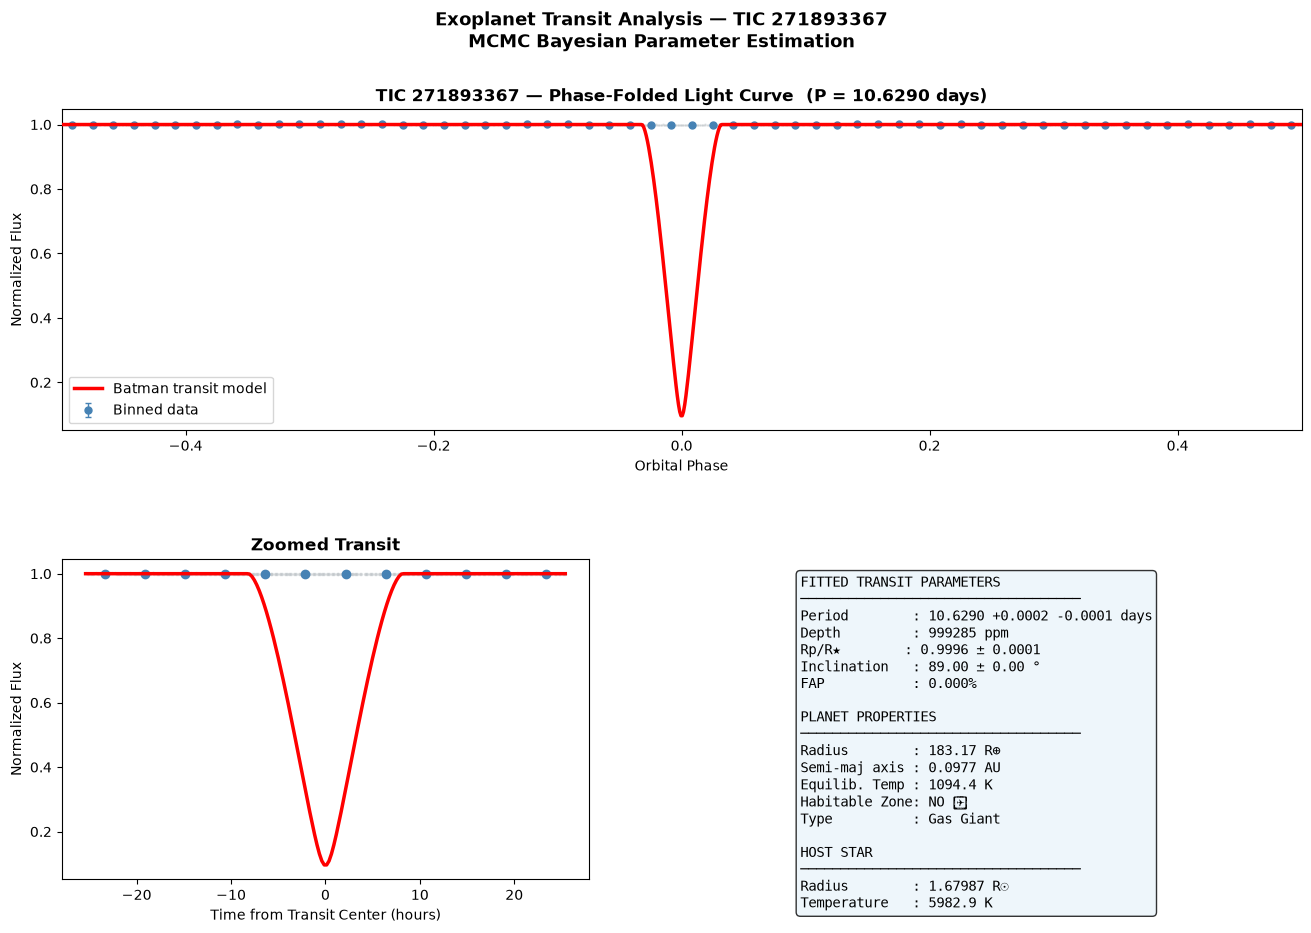

Transit fit plot saved for TIC 271893367!


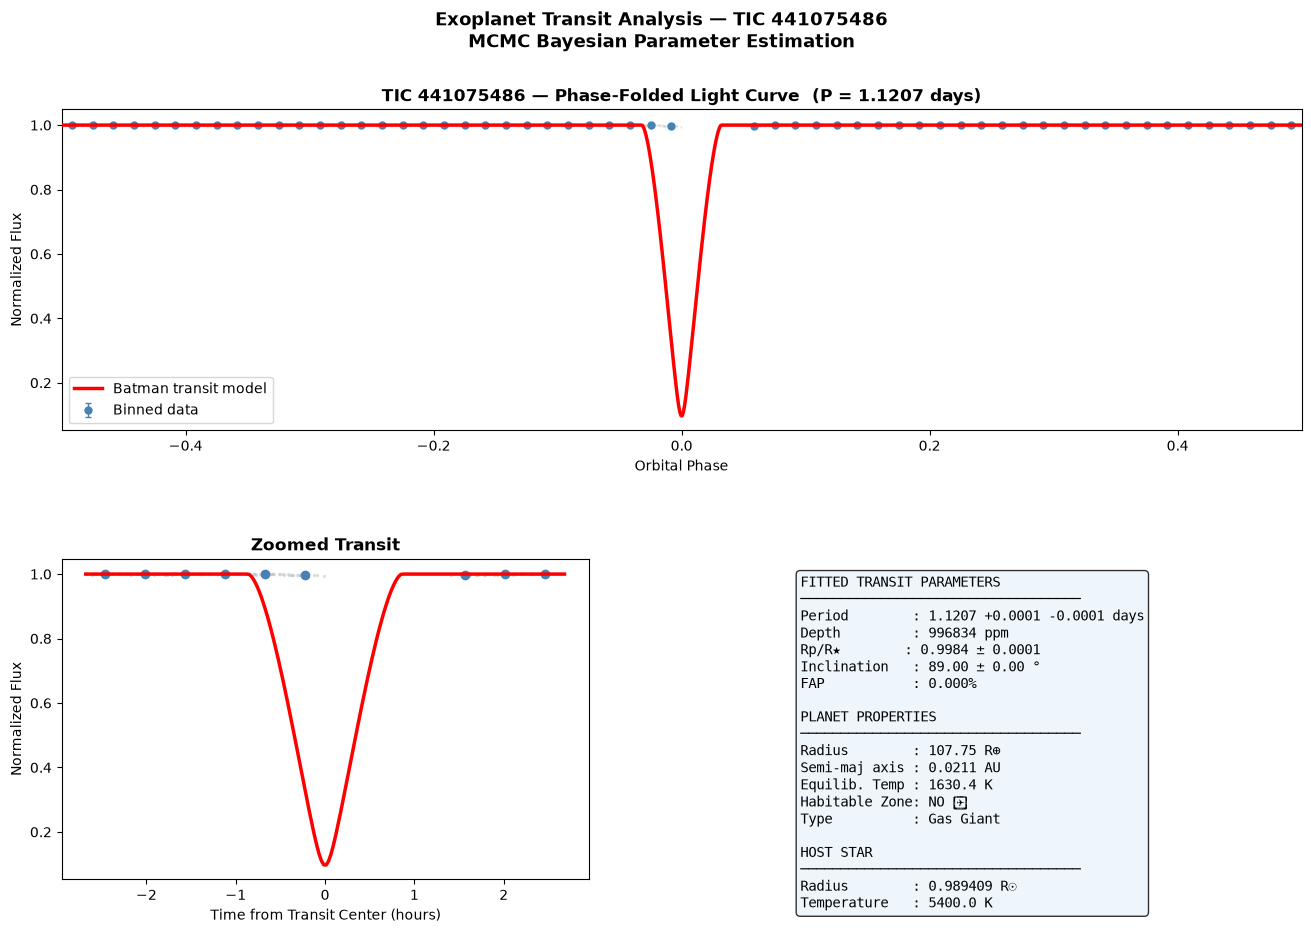

Transit fit plot saved for TIC 441075486!


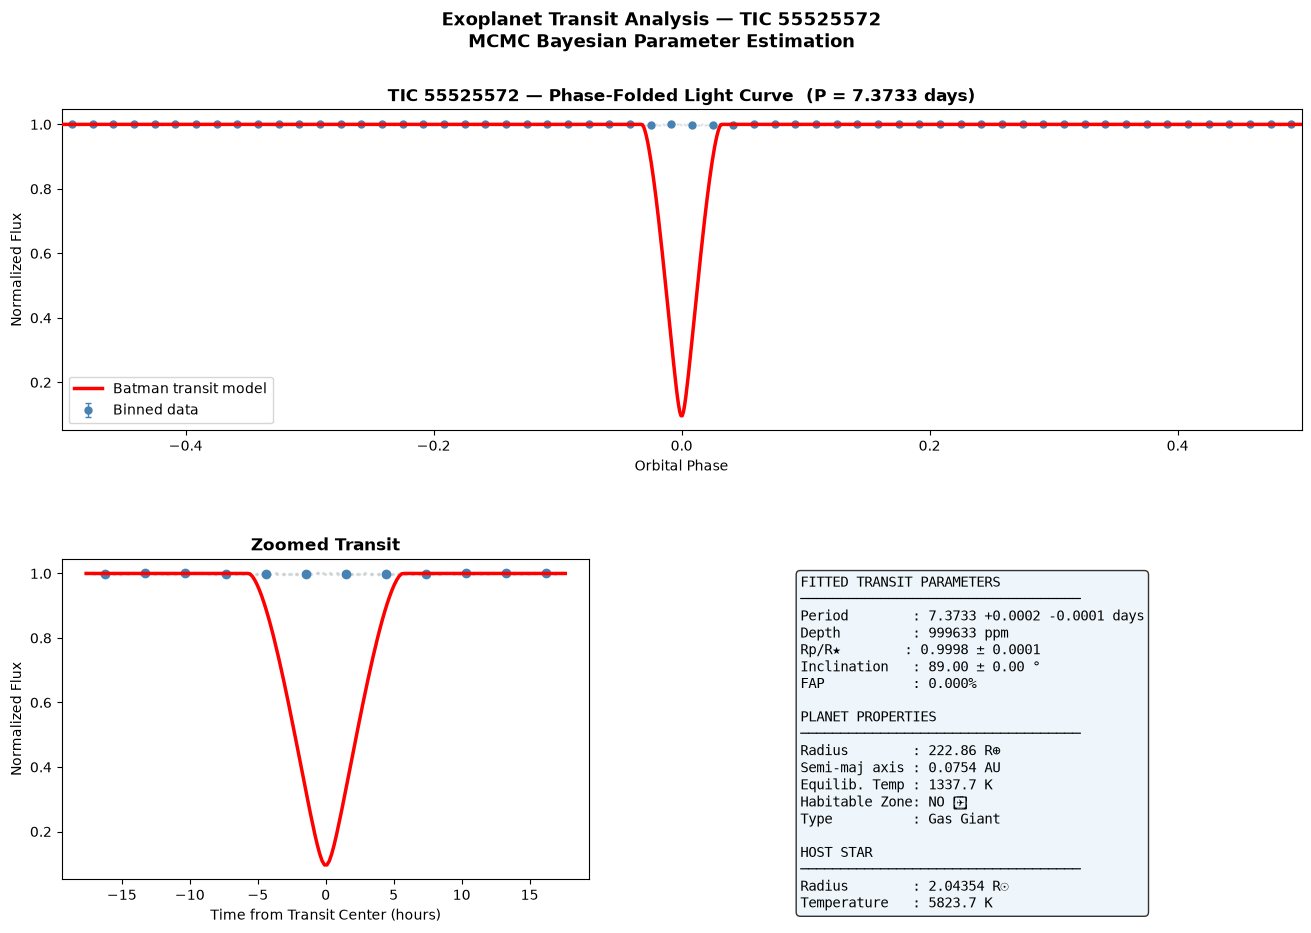

Transit fit plot saved for TIC 55525572!


In [13]:
for tic_id, mcmc_res in mcmc_results.items():
    try:
        df       = pd.read_csv(os.path.join(PROCESSED_DIR, f'TIC_{tic_id}.csv'))
        time     = df['time'].values
        flux     = df['flux'].values
        flux_err = df['flux_err'].values if 'flux_err' in df.columns else \
                   np.ones_like(flux) * np.std(flux)
        mask     = np.isfinite(time) & np.isfinite(flux)
        time, flux, flux_err = time[mask], flux[mask], flux_err[mask]

        period = mcmc_res['period'][0]
        bls_row= bls_df[bls_df['tic_id']==tic_id].iloc[0]
        t0     = float(bls_row['transit_time'])
        rp     = mcmc_res['rp'][0]
        a      = mcmc_res['a'][0]
        inc    = mcmc_res['inc'][0]

        # Phase fold
        phase  = ((time - t0) % period) / period
        phase[phase > 0.5] -= 1.0
        sidx   = np.argsort(phase)
        phase_s, flux_s = phase[sidx], flux[sidx]

        # Binned
        bins     = np.linspace(-0.5, 0.5, 61)
        bin_mid  = (bins[:-1]+bins[1:])/2
        bin_flux = [np.nanmedian(flux_s[(phase_s>=bins[i])&(phase_s<bins[i+1])])
                    for i in range(60)]
        bin_std  = [np.nanstd(flux_s[(phase_s>=bins[i])&(phase_s<bins[i+1])])
                    if np.any((phase_s>=bins[i])&(phase_s<bins[i+1])) else 0
                    for i in range(60)]

        # Batman model
        phase_fine = np.linspace(-0.5, 0.5, 1000)
        time_fine  = t0 + phase_fine * period
        if BATMAN_OK:
            model_flux = batman_model(time_fine, t0, period, rp, a, inc)
        else:
            model_flux = np.ones_like(time_fine)

        # Get planet params
        pparams = next((p for p in planet_params_list if p['tic_id']==tic_id), {})
        fap_val = fap_results.get(tic_id, {}).get('fap', None)
        fap_str = f'{fap_val*100:.3f}%' if fap_val is not None else 'N/A'

        # Plot
        fig = plt.figure(figsize=(16, 10))
        gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

        # Panel A — Full phase fold
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(phase_s, flux_s, '.', color='#bdc3c7', markersize=1.5, alpha=0.3)
        ax1.errorbar(bin_mid, bin_flux, yerr=bin_std,
                     fmt='o', color='steelblue', markersize=5,
                     elinewidth=1, capsize=2, label='Binned data', zorder=5)
        if BATMAN_OK:
            ax1.plot(phase_fine, model_flux, 'r-', lw=2.5,
                     label='Batman transit model', zorder=6)
        ax1.set_xlim(-0.5, 0.5)
        ax1.set_xlabel('Orbital Phase')
        ax1.set_ylabel('Normalized Flux')
        ax1.set_title(f'TIC {tic_id} — Phase-Folded Light Curve  '
                      f'(P = {period:.4f} days)', fontweight='bold')
        ax1.legend(fontsize=10)

        # Panel B — Zoomed transit
        ax2 = fig.add_subplot(gs[1, 0])
        zoom = 0.1
        zm   = np.abs(phase_s) < zoom
        ax2.plot(phase_s[zm]*period*24, flux_s[zm],
                 '.', color='#bdc3c7', markersize=3, alpha=0.4)
        bm2  = np.abs(bin_mid) < zoom
        ax2.errorbar(bin_mid[bm2]*period*24, np.array(bin_flux)[bm2],
                     yerr=np.array(bin_std)[bm2],
                     fmt='o', color='steelblue', markersize=6,
                     elinewidth=1.5, capsize=3, zorder=5)
        if BATMAN_OK:
            fine_zm = np.abs(phase_fine) < zoom
            ax2.plot(phase_fine[fine_zm]*period*24, model_flux[fine_zm],
                     'r-', lw=2.5, zorder=6)
        ax2.set_xlabel('Time from Transit Center (hours)')
        ax2.set_ylabel('Normalized Flux')
        ax2.set_title('Zoomed Transit', fontweight='bold')

        # Panel C — Parameter summary text box
        ax3 = fig.add_subplot(gs[1, 1])
        ax3.axis('off')

        summary_text = (
            f"FITTED TRANSIT PARAMETERS\n"
            f"{'─'*35}\n"
            f"Period        : {mcmc_res['period'][0]:.4f} "
            f"+{mcmc_res['period'][1]:.4f} -{mcmc_res['period'][2]:.4f} days\n"
            f"Depth         : {rp**2*1e6:.0f} ppm\n"
            f"Rp/R★        : {rp:.4f} ± {mcmc_res['rp'][1]:.4f}\n"
            f"Inclination   : {inc:.2f} ± {mcmc_res['inc'][1]:.2f} °\n"
            f"FAP           : {fap_str}\n\n"
            f"PLANET PROPERTIES\n"
            f"{'─'*35}\n"
            f"Radius        : {pparams.get('radius_earth','?')} R⊕\n"
            f"Semi-maj axis : {pparams.get('sma_au','?')} AU\n"
            f"Equilib. Temp : {pparams.get('teq_kelvin','?')} K\n"
            f"Habitable Zone: {'YES ✅' if pparams.get('in_habitable_zone') else 'NO ❌'}\n"
            f"Type          : {pparams.get('planet_type','?')}\n\n"
            f"HOST STAR\n"
            f"{'─'*35}\n"
            f"Radius        : {pparams.get('star_radius_sun','?')} R☉\n"
            f"Temperature   : {pparams.get('star_teff','?')} K"
        )

        ax3.text(0.05, 0.95, summary_text,
                 transform=ax3.transAxes,
                 fontsize=10, verticalalignment='top',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='#eaf4fb', alpha=0.8))

        plt.suptitle(
            f'Exoplanet Transit Analysis — TIC {tic_id}\n'
            f'MCMC Bayesian Parameter Estimation',
            fontsize=13, fontweight='bold'
        )

        plt.savefig(
            os.path.join(PLOTS_DIR, f'FIGURE_transit_fit_TIC{tic_id}.png'),
            dpi=200, bbox_inches='tight'
        )
        plt.show()
        print(f'Transit fit plot saved for TIC {tic_id}!')

    except Exception as e:
        print(f'Plot failed for TIC {tic_id}: {e}')
        import traceback
        traceback.print_exc()

## 10. FAP Visualization

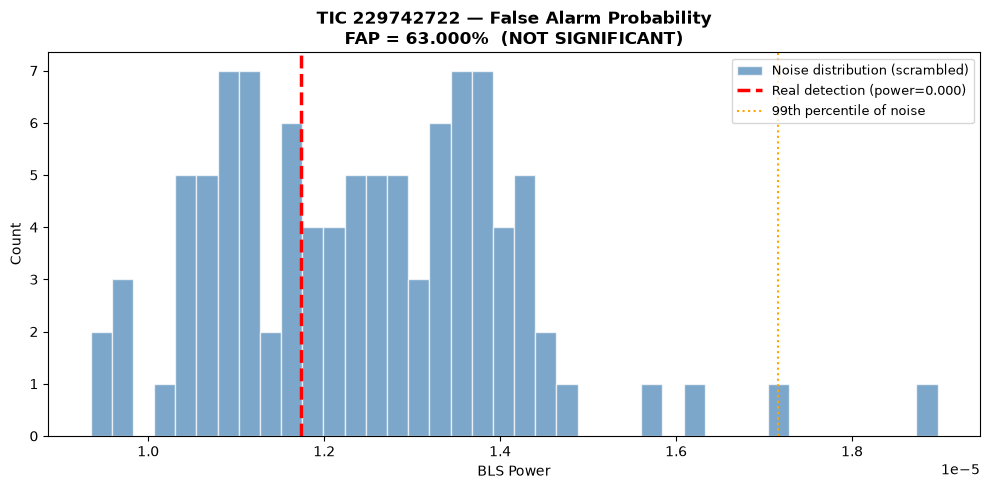

FAP plot saved for TIC 229742722!


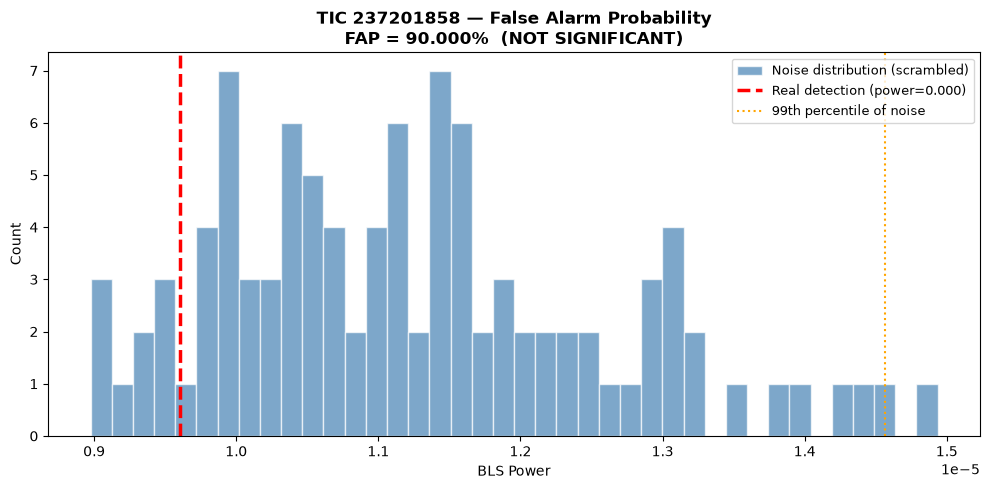

FAP plot saved for TIC 237201858!


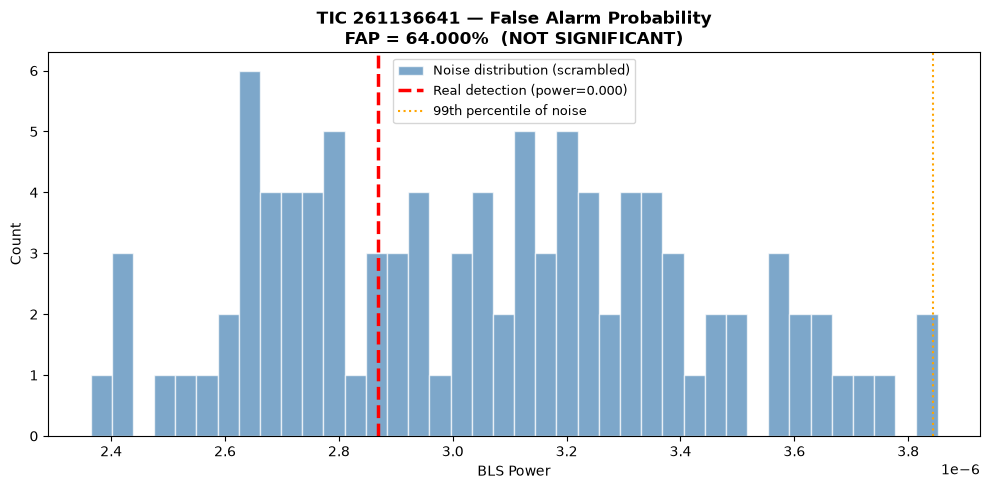

FAP plot saved for TIC 261136641!


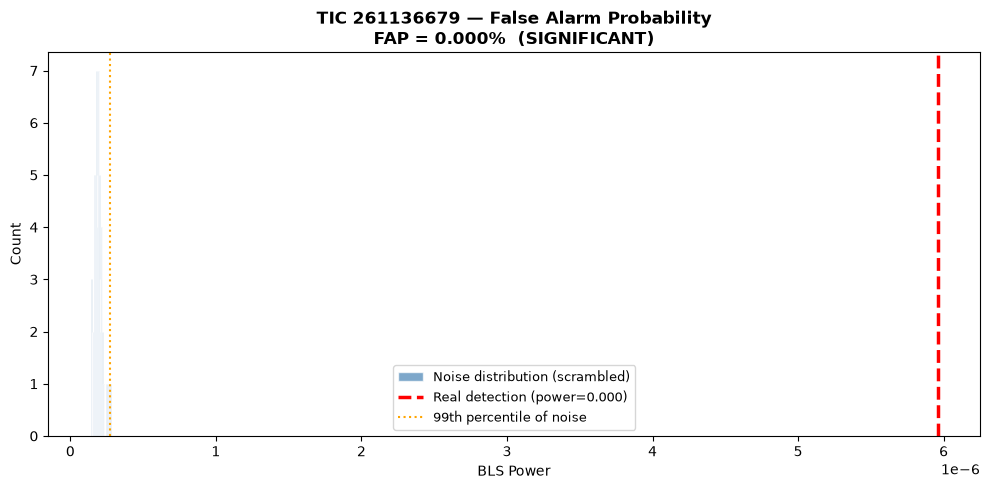

FAP plot saved for TIC 261136679!


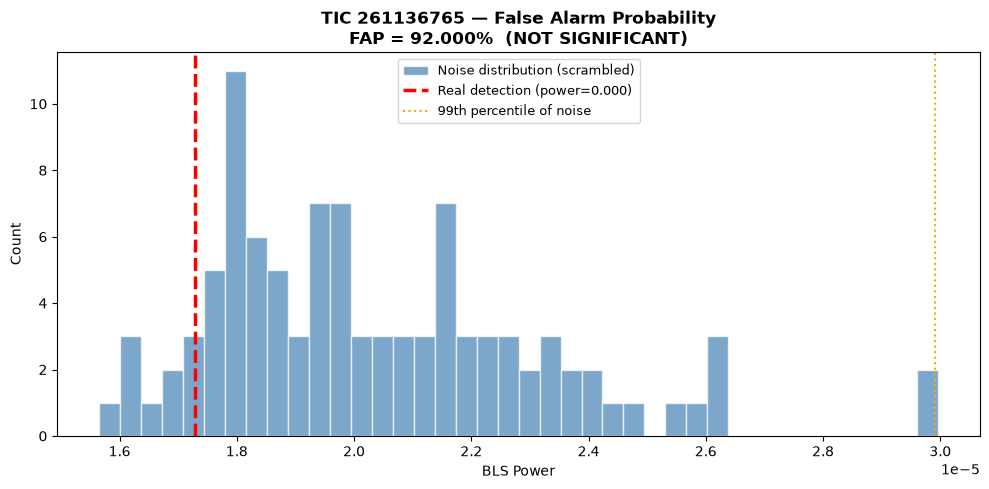

FAP plot saved for TIC 261136765!


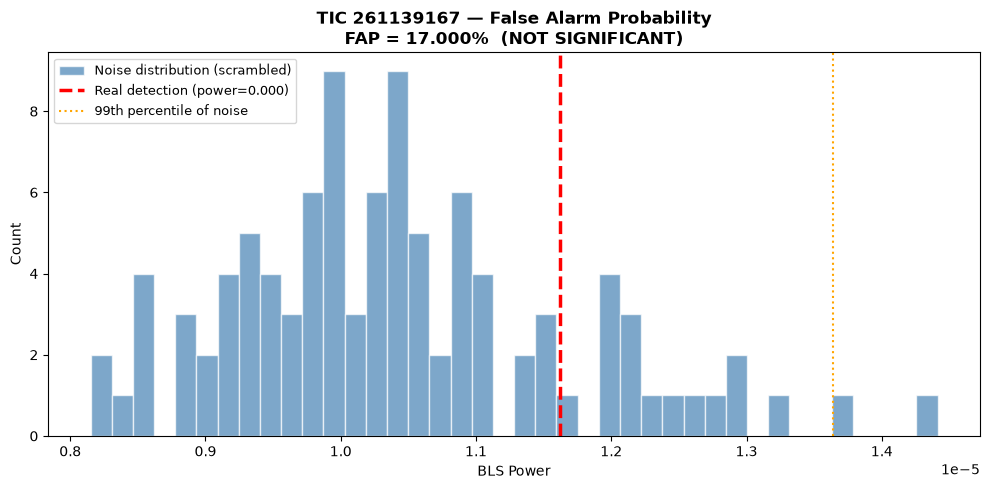

FAP plot saved for TIC 261139167!


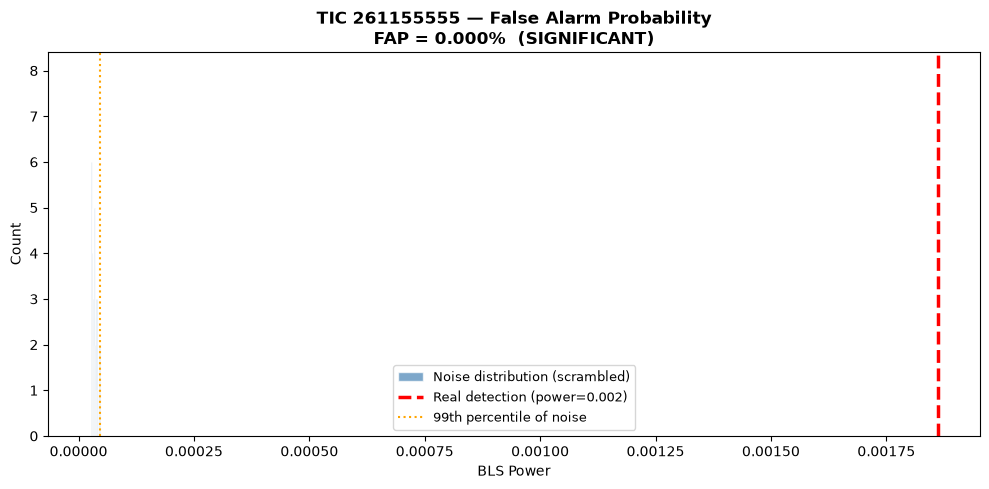

FAP plot saved for TIC 261155555!


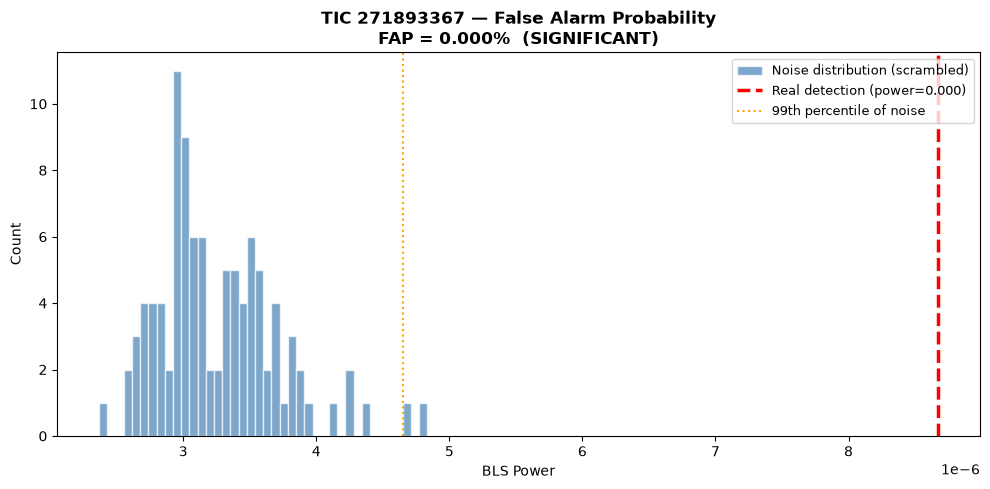

FAP plot saved for TIC 271893367!


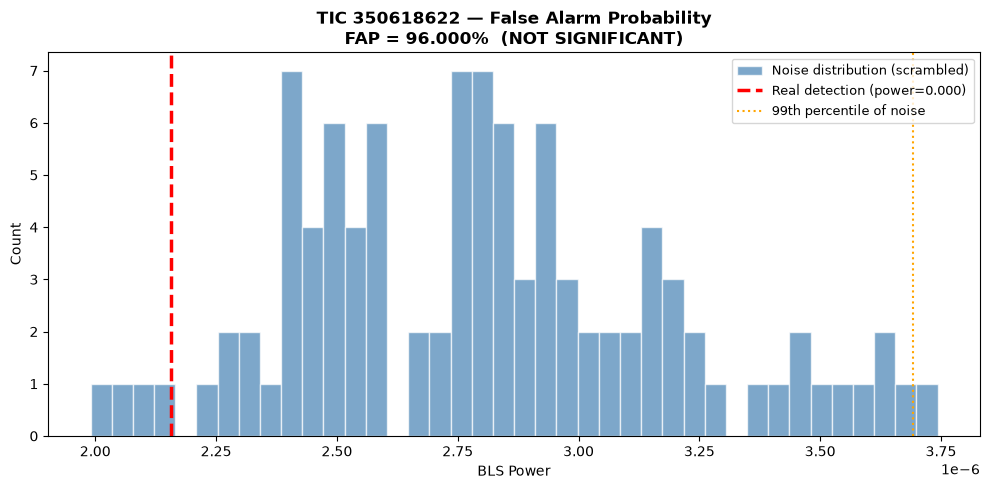

FAP plot saved for TIC 350618622!


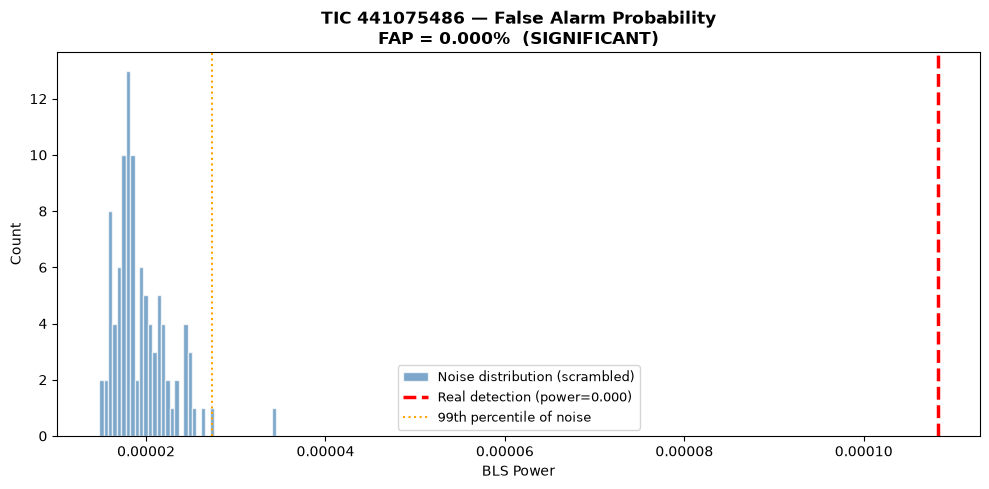

FAP plot saved for TIC 441075486!


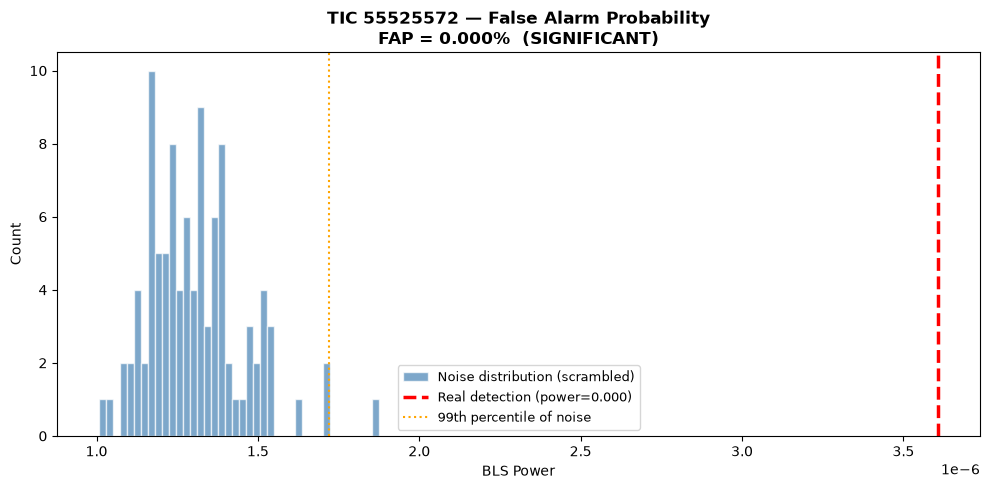

FAP plot saved for TIC 55525572!


In [14]:
for tic_id, fap_data in fap_results.items():
    if not fap_data.get('noise_powers'):
        continue

    fig, ax = plt.subplots(figsize=(10, 5))

    noise = np.array(fap_data['noise_powers'])
    real  = fap_data['real_power']
    fap   = fap_data['fap']

    ax.hist(noise, bins=40, color='steelblue', alpha=0.7,
            edgecolor='white', label='Noise distribution (scrambled)')
    ax.axvline(real, color='red', lw=2.5, linestyle='--',
               label=f'Real detection (power={real:.3f})')
    ax.axvline(np.percentile(noise, 99), color='orange', lw=1.5,
               linestyle=':', label='99th percentile of noise')

    ax.set_xlabel('BLS Power')
    ax.set_ylabel('Count')
    ax.set_title(
        f'TIC {tic_id} — False Alarm Probability\n'
        f'FAP = {fap*100:.3f}%  '
        f'({"SIGNIFICANT" if fap < 0.01 else "MARGINAL" if fap < 0.05 else "NOT SIGNIFICANT"})',
        fontweight='bold'
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_DIR, f'FAP_TIC{tic_id}.png'),
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f'FAP plot saved for TIC {tic_id}!')

---
## ✅ Done!
**What was saved:**
- `outputs/planet_parameters.csv` — full physical parameters for all candidates
- `outputs/plots/FIGURE_transit_fit_TIC*.png` — transit fit + parameter summary
- `outputs/plots/corner_TIC*.png` — MCMC posterior distributions
- `outputs/plots/FAP_TIC*.png` — false alarm probability plots

**Next Step → Run `08_visualization.ipynb` then `09_validation.ipynb`**